# Feature Selection — Fase 1: Evaluación directa multi-ventana

**Versión:** 3.0  
**Estado:** Pendiente de revisión del asesor  
**Equipo:** PredictaMaintenance

---

## 1. Contexto y Motivación

### 1.1 Dataset: NASA C-MAPSS FD001

C-MAPSS FD001 contiene datos de degradación hasta fallo de motores turbofan de aeronaves:

| Propiedad | Valor |
|-----------|-------|
| Total de motores | 200 |
| Conjunto de entrenamiento (70%) | 140 motores |
| Conjunto de prueba (30%) | 60 motores |
| Sensores | 21 originales → 16 tras eliminar varianza cero |
| Condiciones operativas | 1 |
| Modos de fallo | 1 |
| Ciclos por motor | 128–362 |
| Indicador de evento | evento=1 únicamente en el último ciclo de cada motor de entrenamiento |

El dataset fue diseñado para regresión de RUL. Cada motor tiene exactamente un evento terminal al final de su vida operativa.

### 1.2 Arquitectura del Pipeline

```
Sensores crudos (unit_number, time_in_cycles, sensores, evento)
    ↓
Nodo 2 — build_windows(window_size)
    Ventanas deslizantes de window_size ciclos por motor
    Salida: (n_ventanas, window_size, n_sensores) por motor
    ↓
Nodo 3 — extract_window_features(feature_set)
    Características estadísticas sobre el eje de ventana
    Salida: (n_ventanas, n_características) por motor
    ↓
Nodo 4 — DimReducer(n_components)
    RobustScaler interno + PCA Global
    Ajustado únicamente sobre datos de entrenamiento (sin data leakage)
    Salida: (n_ventanas, n_components) por motor
    ↓
Modelo (NB, SVR, etc.)
    Recibe matriz plana (total_ventanas, n_components)
    El modelo es agnóstico al motor
```

**Decisiones de diseño validadas:**
- Nodo 1 (FeatureScaler sobre sensores crudos) eliminado — redundante dado el RobustScaler del DimReducer
- PCA ajustado globalmente sobre todos los motores de entrenamiento concatenados — no por motor
- clipping_threshold afecta únicamente y_rul, no las características X

### 1.3 Características Disponibles

Las características candidatas se organizan en cinco dominios:

| Dominio | Características | Costo |
|---------|----------------|-------|
| Estadístico | mean, std, rms, median, q25, q75 | O(n) |
| Tendencia | slope, rvalue | O(n) |
| Autocorrelación | autocorr_lag_1/2 | O(n) |
| Memoria | runs_ratio, hurst_rs | O(n) |
| Frecuencia | fft_coef_1/2/3 | O(n log n) |
| Complejidad | permutation_entropy | O(n) — lento en práctica |

---

## 2. Pregunta de Investigación

> **¿Qué combinación de características estadísticas extraídas sobre ventanas deslizantes permite al modelo predictor estimar mejor el RUL de motores no vistos durante el entrenamiento?**

### 2.1 Evolución del criterio de selección

La selección del criterio de evaluación pasó por tres etapas durante el desarrollo del proyecto:

**Etapa 1 — cumvar del PCA (descartado):**
Se propuso inicialmente usar la varianza explicada acumulada del PCA con n_components fijo como criterio. Esta métrica fue descartada porque es matemáticamente inválida para comparar conjuntos de diferente dimensionalidad: con datos estandarizados, la varianza total es igual a p (número de features), por lo que cumvar con n_components fijo penaliza sistemáticamente los conjuntos más grandes.

**Etapa 2 — Autovalor promedio como exploración preliminar:**
Para corregir el sesgo de dimensionalidad se propuso el autovalor promedio:

```
ratio = cumvar × (p / n_components) = (1/k) Σ λ_i
```

Esta métrica es comparable entre conjuntos de diferente dimensionalidad porque expresa la varianza absoluta promedio capturada por cada PC, independientemente de p. Se usa como **acercamiento preliminar** para orientar la búsqueda y descartar conjuntos claramente dominados.

**Etapa 3 — Rendimiento predictivo real como criterio definitivo:**
El criterio final es el rendimiento del modelo predictor (MAE, RMSE, S-Score) en validación cruzada GroupKFold. El asesor señaló correctamente que "el modelo debería ser quien decida" — la selección de features no puede desacoplarse del modelo que las consume. Este enfoque es el más defendible en un paper de investigación porque mide directamente el objetivo del pipeline.

### 2.2 Por qué el rendimiento predictivo como criterio definitivo

- Mide directamente la precisión en RUL — el objetivo real del pipeline ✅
- No asume linealidad entre features y RUL ✅
- Validado mediante GroupKFold por motor — sin data leakage ✅
- Estándar en competiciones PHM y revistas de fiabilidad ✅
- Permite que cada conjunto encuentre su n_components óptimo ✅

---

## 3. Conjuntos Candidatos de Características

Se evalúan cuatro conjuntos en el GGS definitivo, seleccionados mediante el análisis preliminar de autovalor promedio. Un quinto conjunto (E) fue descartado por viabilidad computacional.

### 3.1 Definición de los Conjuntos

---

**Conjunto A — Baseline mínimo**

*Composición:* `mean`, `std`, `rms`, `slope`, `rvalue`
*Dimensión:* 5 tipos × 16 sensores = **80 características**
*Rol:* Ancla inferior — permite cuantificar la mejora de conjuntos más ricos

*Justificación:* Representa el conjunto mínimo coherente para capturar el nivel, la dispersión y la tendencia temporal de cada sensor. Si C o D no superan significativamente a A en rendimiento predictivo, se justifica una implementación minimal.

---

**Conjunto B — Referencia del pipeline actual**

*Composición:* `median`, `rms`, `q25`, `q75`, `slope`, `rvalue`, `autocorr_lag_1`, `autocorr_lag_2`
*Dimensión:* 8 tipos × 16 sensores = **128 características**
*Rol:* Referencia — mide la mejora respecto al estado anterior del pipeline

*Justificación:* Refleja el conjunto actual de PredictaMaintenance. Usa `median` y cuantiles por su robustez ante valores atípicos en ciclos tardíos. Incluye los dos primeros lags de autocorrelación para capturar persistencia de corto plazo.

*Nota:* `abs_energy` fue reemplazado por `rms` — misma información pero sin explosión numérica (rms ~ 9,000 vs abs_energy ~ 2.4×10⁹).

---

**Conjunto C — +Memoria temporal**

*Composición:* B + `runs_ratio`, `hurst_rs`
*Dimensión:* 10 tipos × 16 sensores = **160 características**
*Rol:* Candidato — evalúa si la memoria temporal mejora la predicción

*Justificación de las características añadidas:*

**runs_ratio** — proporción de rachas de signos en las primeras diferencias:
```
d_t = sign(x_t - x_{t-1})
runs_ratio = n_rachas(d_t) / (window_size - 1)
```
Mide persistencia direccional no lineal — bajo si la señal sigue una dirección, alto si alterna caóticamente. Costo: O(n).

**hurst_rs** — exponente de Hurst por rango reescalado:
```
R/S = (max(cumsum(x - mean)) - min(cumsum(x - mean))) / std(x)
hurst_rs = log(R/S) / log(n)
```
H > 0.5 indica persistencia; H < 0.5 antipersistencia. Captura memoria larga no cubierta por autocorr_lag_1/2. Costo: O(n).

*Por qué no partial_autocorr:* Yule-Walker es O(n²) por ventana por sensor — prohibitivo para el GGS.

---

**Conjunto D — +Frecuencia**

*Composición:* B + `fft_coef_1`, `fft_coef_2`, `fft_coef_3`
*Dimensión:* 11 tipos × 16 sensores = **176 características**
*Rol:* Candidato favorito según análisis preliminar

*Justificación:* Los coeficientes FFT capturan la amplitud de las frecuencias dominantes dentro de la ventana. Alomari et al. (2023) identifican que PC1 está fuertemente influenciado por coeficientes FFT de sensores de temperatura y presión.

*Nota:* fft_coef_0 excluido — proporcional a mean(x), redundante con median ya presente en B. Frecuencias > 3 excluidas para window_size=20 — dominadas por ruido.

---

**Conjunto E — DESCARTADO**

*Composición original:* B + `permutation_entropy`
*Razón de descarte:* Costo computacional de 284s para 140 motores (25× más lento que D). El autovalor promedio de E (6.22) es prácticamente idéntico al de B (6.25), lo que indica que la permutation_entropy no aporta información adicional relevante a pesar de su alto costo. Incluirlo en el GGS añadiría ~70 minutos solo en extracción de features sin beneficio esperado.

*Documentación:* El descarte se aplica antes del GGS basándose en el filtro de viabilidad computacional — sin sesgo de selección porque no se observaron métricas predictivas.

---

### 3.2 Resumen de Conjuntos para el GGS

| Conjunto | Características | p | Ratio preliminar | Tiempo (4 ws) | Rol |
|----------|----------------|---|------------------|---------------|-----|
| A | mean, std, rms, slope, rvalue | 80 | 4.19 | 1.8s | Baseline |
| B | median, rms, q25, q75, slope, rvalue, autocorr×2 | 128 | 6.25 | 8.4s | Referencia |
| C | B + runs_ratio, hurst_rs | 160 | 6.74 | 11.3s | Candidato |
| **D** | **B + fft_coef_1/2/3** | **176** | **7.16** | **10.5s** | **Favorito** |
| ~~E~~ | ~~B + permutation_entropy~~ | ~~144~~ | ~~6.22~~ | ~~284.3s~~ | ~~Descartado~~ |

---

## 4. Análisis Preliminar — Autovalor Promedio

### 4.1 Métrica

El autovalor promedio corrige el sesgo de dimensionalidad del cumvar simple:

```
ratio = cumvar × (p / n_components) = (1/k) Σ λ_i

Donde:
    cumvar      = varianza explicada acumulada por los k primeros PCs
    p           = número de características del conjunto
    n_components = k = 15 (fijo para el análisis preliminar)
    λ_i         = i-ésimo autovalor de la matriz de covarianza (datos estandarizados)
```

**Interpretación:** expresa cuánta varianza, en unidades de la varianza de una característica original, retiene cada PC en promedio. Ratio > 1 indica que los PCs capturan más varianza que una característica aleatoria — ratio = 1 equivaldría a ruido blanco.

**Validez:** comparable entre conjuntos de diferente p porque la varianza total de datos estandarizados es exactamente p, y la división por p en el ratio la cancela.

**Limitación:** mide varianza, no relevancia predictiva. Dos conjuntos con igual ratio pueden tener diferente utilidad para predecir RUL si la varianza capturada está correlacionada con el target en diferente medida.

### 4.2 Procedimiento

```
Para cada window_size ∈ {15, 20, 25, 30}:
    Para cada conjunto (A, B, C, D, E):
        1. Cargar los 140 motores de entrenamiento
        2. build_windows(window_size)
        3. extract_window_features(conjunto)
        4. Concatenar globalmente: X_global (n_ventanas_total, p)
        5. RobustScaler + PCA(n_components=15)
        6. ratio = cumvar × p / 15
```

### 4.3 Resultados

**Tabla de ratio ajustado por conjunto y window_size:**

| Conjunto | ws=15 | ws=20 | ws=25 | ws=30 | Media | Std |
|----------|-------|-------|-------|-------|-------|-----|
| A | 3.917 | 4.102 | 4.284 | 4.449 | 4.188 | 0.199 |
| B | 5.995 | 6.151 | 6.331 | 6.514 | 6.248 | 0.194 |
| C | 6.330 | 6.568 | 6.911 | 7.144 | 6.738 | 0.313 |
| **D** | **6.534** | **6.945** | **7.382** | **7.797** | **7.165** | **0.472** |
| E | 6.174 | 6.069 | 6.205 | 6.439 | 6.222 | 0.135 |

**Ranking por window_size:**

| window_size | Ranking |
|-------------|---------|
| ws=15 | D > C > E > B > A |
| ws=20 | D > C > B > E > A |
| ws=25 | D > C > B > E > A |
| ws=30 | D > C > B > E > A |

**Top-2 estable:** D > C en todos los window_sizes ✅

**Observaciones:**
- D es el candidato favorito con ratio medio 7.165 — consistentemente superior
- A es el más débil (ratio 4.188) — confirma que el baseline mínimo no es suficiente bajo la métrica correcta
- E tiene ratio casi idéntico a B (6.22 vs 6.25) con costo 25× mayor → descarte justificado
- El ratio crece monotónicamente con window_size en todos los conjuntos — ventanas más largas retienen más información

### 4.4 Limitación del análisis preliminar

La comparación por ratio ajustado no garantiza que D sea el mejor conjunto para predecir RUL — solo que concentra más varianza absoluta en los primeros 15 PCs. La selección definitiva requiere evaluar el rendimiento predictivo real mediante el GGS.

---

## 5. Selección Definitiva — Group Grid Search

### 5.1 Justificación del enfoque

El feature_set se incorpora como hiperparámetro del GGS junto con window_size y n_components. Este enfoque:

- Mide directamente la precisión en RUL bajo condiciones reales del pipeline ✅
- Permite que cada conjunto encuentre su n_components óptimo — comparación justa ✅
- GroupKFold por motor garantiza ausencia de data leakage ✅
- Es el estándar en la literatura de PHM para selección de características ✅

### 5.2 Espacio de búsqueda

```python
param_grid = {
    # Hiperparámetros del pipeline
    'feature_set':  ['A', 'B', 'C', 'D'],
    'window_size':  [15, 20, 25, 30],
    'n_components': [10, 15, 20],

    # Hiperparámetros del modelo (por separado para NB y SVR)
    # NB:  alpha, alpha_reg, l1_ratio, link_type
    # SVR: C, epsilon, kernel, gamma
}
```

**Combinaciones de pipeline:** 4 sets × 4 window_sizes × 3 n_components = **48 combinaciones**
**Con 5 folds GroupKFold:** 48 × 5 = **240 fits por modelo**

### 5.3 Métricas de evaluación

- **MAE** — error absoluto medio en ciclos (interpretable físicamente)
- **RMSE** — penaliza errores grandes
- **S-Score** — función asimétrica NASA: penaliza más las sobreestimaciones de RUL

### 5.4 Criterio de selección final

Se selecciona la combinación (feature_set, window_size, n_components, hiperparámetros_modelo) que minimiza el MAE medio en validación cruzada. En caso de empate dentro del margen de std, se prefiere el conjunto con menor dimensionalidad por parsimonia.

### 5.5 Control de sesgo de selección

- El GGS se ejecuta exclusivamente sobre los 140 motores de entrenamiento
- Los 60 motores de test se reservan para evaluación final — nunca vistos durante la selección
- GroupKFold garantiza que las ventanas de un mismo motor no se dividen entre folds
- El análisis preliminar de ratio ajustado (Sección 4) se aplicó antes de observar métricas predictivas — sin sesgo de selección retrospectivo

---

## 6. Resumen del Proceso Metodológico

```
Paso 1 — Definición de conjuntos candidatos
    5 conjuntos (A-E) diseñados para explorar diferentes dominios:
    distribución, tendencia, memoria, frecuencia, complejidad

Paso 2 — Filtro de viabilidad computacional
    SET E descartado: ratio similar a B (6.22 vs 6.25), costo 25× mayor
    Quedan 4 conjuntos para el GGS: A, B, C, D

Paso 3 — Análisis preliminar de autovalor promedio
    Orientación: D > C > B > A en ratio ajustado
    Conclusión: D es el candidato favorito, pero la selección es del GGS

Paso 4 — Group Grid Search (criterio definitivo)
    feature_set como hiperparámetro junto con window_size y n_components
    Criterio: MAE/RMSE/S-Score en GroupKFold por motor
    Selección: combinación con mejor rendimiento predictivo real
```

---

## 7. Preguntas Abiertas para el Asesor

1. ¿Es el autovalor promedio (ratio = cumvar × p / n_components) suficiente como justificación del filtro preliminar para descartar SET E en el paper, o se requiere una validación predictiva reducida de E?

2. ¿Debería n_components explorarse con rangos diferentes por conjunto (ej. más amplio para D que para A) dado que D tiene mayor dimensionalidad original?

3. ¿Es el S-Score de la NASA una métrica obligatoria para este paper, o MAE y RMSE son suficientes dado el contexto académico?

4. ¿Se reporta el análisis de ratio ajustado como sección metodológica del paper, o solo como nota interna de desarrollo?

FEATURE SELECTION — Fase 1: Acercamiento Preliminar
Métrica: autovalor promedio (ratio = cumvar × p / n_components)

Cargando motores de entrenamiento... Training engines: 140
Test engines: 60
1.1s
  Motores: 140, Filas: 23824

─────────────────────────────────────────────────────────────────
EVALUACIÓN: 5 conjuntos × 4 window_sizes
─────────────────────────────────────────────────────────────────

  window_size = 15
    Windowing: 0.71s (21864 ventanas)
    [A] p= 80  feat_time=0.4s  cumvar=0.7345  ratio=3.9171
    [B] p=128  feat_time=1.5s  cumvar=0.7026  ratio=5.9953
    [C] p=160  feat_time=2.9s  cumvar=0.5934  ratio=6.3297
    [D] p=176  feat_time=2.2s  cumvar=0.5569  ratio=6.5338
    [E] p=144  feat_time=48.1s  cumvar=0.6432  ratio=6.1744

  window_size = 20
    Windowing: 0.61s (21164 ventanas)
    [A] p= 80  feat_time=0.4s  cumvar=0.7692  ratio=4.1023
    [B] p=128  feat_time=2.3s  cumvar=0.7208  ratio=6.1507
    [C] p=160  feat_time=2.1s  cumvar=0.6157  ratio=6.5678
    [D] p=

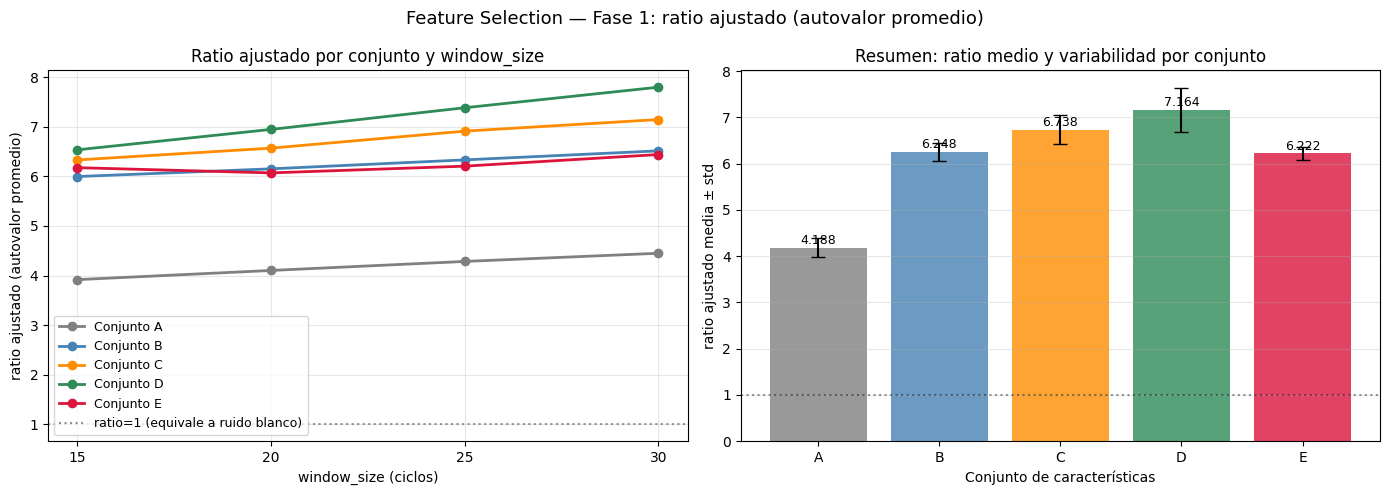


Gráfico guardado: feature_selection_phase1.png


In [1]:
"""Feature Selection — Fase 1: Evaluación directa multi-ventana.

Evalúa los 5 conjuntos candidatos de características (A-E) sobre los
140 motores de entrenamiento para 4 tamaños de ventana {15, 20, 25, 30}.

Métrica: autovalor promedio de los primeros n_components PCs:

    ratio = cumvar × (p / n_components) = (1/k) Σ λ_i

Donde p = número de características del conjunto, k = n_components = 15.
Esta métrica es comparable entre conjuntos de diferente dimensionalidad —
a diferencia del cumvar simple que penaliza sistemáticamente los conjuntos
más grandes por tener más varianza total que comprimir.

Uso: acercamiento preliminar antes del GGS con feature_set como
hiperparámetro. Los resultados orientan la búsqueda pero la selección
definitiva la realiza el modelo predictor en validación cruzada.

Run desde el proyecto root:
    python feature_selection_phase1.py
"""

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

from src.dataset_manager import DatasetManager
from src.pipeline.windowing import build_windows, flatten_windows
from src.pipeline.feature_extraction import (
    extract_window_features,
    FEATURE_SETS,
)

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
WINDOW_SIZES    = [15, 20, 25, 30]
N_COMPONENTS    = 15
CLIPPING        = 125
THRESHOLD_RATIO = 0.5   # diferencia mínima en ratio ajustado para ranking claro

print("=" * 65)
print("FEATURE SELECTION — Fase 1: Acercamiento Preliminar")
print("Métrica: autovalor promedio (ratio = cumvar × p / n_components)")
print("=" * 65)

# ---------------------------------------------------------------------------
# Cargar los 140 motores de entrenamiento
# ---------------------------------------------------------------------------
print("\nCargando motores de entrenamiento...", end=' ', flush=True)
t0 = time.perf_counter()

m_train, _ = DatasetManager.split_dataset()

dfs = []
for idx in m_train:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df.insert(0, 'unit_number', idx)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
X_df = df_all.drop(columns=['RUL'])

print(f"{time.perf_counter()-t0:.1f}s")
print(f"  Motores: {X_df['unit_number'].nunique()}, "
      f"Filas: {len(X_df)}")

# ---------------------------------------------------------------------------
# Evaluación: conjuntos × window_sizes
# ---------------------------------------------------------------------------
print(f"\n{'─'*65}")
print(f"EVALUACIÓN: {len(FEATURE_SETS)} conjuntos × {len(WINDOW_SIZES)} window_sizes")
print(f"{'─'*65}")

# Matriz de resultados: cumvar[conjunto][window_size]
results: dict[str, dict[int, float]] = {
    name: {} for name in FEATURE_SETS
}

# Timing por conjunto
timing: dict[str, float] = {name: 0.0 for name in FEATURE_SETS}

for ws in WINDOW_SIZES:
    print(f"\n  window_size = {ws}")

    # Nodo 2 — build_windows (una sola vez por window_size)
    t0 = time.perf_counter()
    motor_windows = build_windows(X_df, window_size=ws, clipping_threshold=CLIPPING)
    t_wind = time.perf_counter() - t0
    n_windows = sum(d['X_windows'].shape[0] for d in motor_windows.values())
    print(f"    Windowing: {t_wind:.2f}s ({n_windows} ventanas)")

    for name, features in FEATURE_SETS.items():

        # Nodo 3 — extract features
        t0 = time.perf_counter()
        motor_features = extract_window_features(motor_windows, features=features)
        t_feat = time.perf_counter() - t0

        # Concatenar globalmente
        X_all = np.concatenate(
            [d['X_windows'] for d in motor_features.values()],
            axis=0
        )

        # RobustScaler + PCA
        X_scaled = RobustScaler().fit_transform(X_all)
        pca = PCA(n_components=min(N_COMPONENTS, X_scaled.shape[1]))
        pca.fit(X_scaled)
        cumvar = float(pca.explained_variance_ratio_.cumsum()[-1])
        p = X_all.shape[1]
        ratio = cumvar * p / N_COMPONENTS  # autovalor promedio

        results[name][ws] = ratio
        timing[name] += t_feat

        print(f"    [{name}] p={p:3d}  feat_time={t_feat:.1f}s  "
              f"cumvar={cumvar:.4f}  ratio={ratio:.4f}")

# ---------------------------------------------------------------------------
# Tabla de resultados
# ---------------------------------------------------------------------------
print(f"\n{'─'*65}")
print("TABLA DE RESULTADOS — ratio ajustado (autovalor promedio, n_components=15)")
print("ratio = cumvar × p / n_components = (1/k) Σ λ_i")
print(f"{'─'*65}")

df_results = pd.DataFrame(results).T
df_results.columns = [f'ws={ws}' for ws in WINDOW_SIZES]
df_results.index.name = 'Conjunto'

# Añadir columnas de análisis
df_results['media'] = df_results.mean(axis=1)
df_results['std']   = df_results.std(axis=1)
df_results['min']   = df_results[[f'ws={ws}' for ws in WINDOW_SIZES]].min(axis=1)
df_results['max']   = df_results[[f'ws={ws}' for ws in WINDOW_SIZES]].max(axis=1)

print(f"\n{df_results.round(4).to_string()}")

# ---------------------------------------------------------------------------
# Análisis de ranking
# ---------------------------------------------------------------------------
print(f"\n{'─'*65}")
print("ANÁLISIS DE RANKING POR WINDOW_SIZE")
print(f"{'─'*65}")

rankings = {}
for ws in WINDOW_SIZES:
    col = f'ws={ws}'
    ranking = df_results[col].sort_values(ascending=False)
    rankings[ws] = list(ranking.index)
    print(f"  ws={ws}: {' > '.join(rankings[ws])}")

# ¿El top-2 del ranking es estable?
# Solo importa que el ganador y el segundo sean consistentes
# — intercambios entre posiciones 3-5 son irrelevantes para la decisión.
top2_stable = all(
    rankings[ws][:2] == rankings[WINDOW_SIZES[0]][:2]
    for ws in WINDOW_SIZES[1:]
)
ranking_stable = top2_stable
winner = rankings[WINDOW_SIZES[0]][0]

# ¿La diferencia entre el ganador y el segundo es ≥ umbral?
second = rankings[WINDOW_SIZES[0]][1]
diffs = []
for ws in WINDOW_SIZES:
    col = f'ws={ws}'
    diff = df_results.loc[winner, col] - df_results.loc[second, col]
    diffs.append(diff)
min_diff = min(diffs)
clear_winner = min_diff >= THRESHOLD_RATIO

# ---------------------------------------------------------------------------
# Decisión automática
# ---------------------------------------------------------------------------
print(f"\n{'─'*65}")
print("ORIENTACIÓN PRELIMINAR")
print(f"{'─'*65}")
print(f"  Ganador preliminar:     Conjunto {winner}")
print(f"  Segundo:                Conjunto {second}")
print(f"  Ranking top-2 estable:  {'✅ SÍ' if ranking_stable else '❌ NO'}")
print(f"  Diferencia mínima:      {min_diff:.4f}  (umbral: {THRESHOLD_RATIO})")
print(f"  Diferencia clara:       {'✅ SÍ' if clear_winner else '❌ NO'}")
print(f"\n  ⚠️  NOTA: Estos resultados son preliminares.")
print(f"     La selección definitiva se realiza via GGS con feature_set")
print(f"     como hiperparámetro y rendimiento predictivo (MAE/RMSE) como criterio.")

if ranking_stable and clear_winner:
    print(f"\n  → Conjunto {winner} es candidato fuerte para el GGS.")
    print(f"     Considerar priorizar este conjunto en la búsqueda.")
else:
    print(f"\n  → Ranking poco concluyente — todos los conjuntos")
    print(f"     deben evaluarse en el GGS sin descarte previo.")

# ---------------------------------------------------------------------------
# Timing summary
# ---------------------------------------------------------------------------
print(f"\n{'─'*65}")
print("TIMING DE EXTRACCIÓN (suma sobre todos los window_sizes)")
print(f"{'─'*65}")
for name, t in timing.items():
    n_feat = len(FEATURE_SETS[name]) * 16
    print(f"  Conjunto {name}: {t:.1f}s  ({n_feat} características)")

# ---------------------------------------------------------------------------
# Gráfico
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Feature Selection — Fase 1: ratio ajustado (autovalor promedio)',
    fontsize=13
)

colors = {'A': 'gray', 'B': 'steelblue', 'C': 'darkorange',
          'D': 'seagreen', 'E': 'crimson'}

# Gráfico 1 — ratio vs window_size por conjunto
ax = axes[0]
for name in FEATURE_SETS:
    vals = [results[name][ws] for ws in WINDOW_SIZES]
    ax.plot(WINDOW_SIZES, vals, marker='o', linewidth=2,
            color=colors[name], label=f'Conjunto {name}')
ax.axhline(y=1.0, color='black', linestyle=':', alpha=0.4,
           label='ratio=1 (equivale a ruido blanco)')
ax.set_xlabel('window_size (ciclos)')
ax.set_ylabel('ratio ajustado (autovalor promedio)')
ax.set_title('Ratio ajustado por conjunto y window_size')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(WINDOW_SIZES)

# Gráfico 2 — barras de media ± std por conjunto
ax = axes[1]
names  = list(FEATURE_SETS.keys())
medias = [df_results.loc[n, 'media'] for n in names]
stds   = [df_results.loc[n, 'std']   for n in names]
bars = ax.bar(names, medias, yerr=stds, capsize=5,
              color=[colors[n] for n in names], alpha=0.8)
ax.set_xlabel('Conjunto de características')
ax.set_ylabel('ratio ajustado media ± std')
ax.set_title('Resumen: ratio medio y variabilidad por conjunto')
ax.axhline(y=1.0, color='black', linestyle=':', alpha=0.4)
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('feature_selection_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráfico guardado: feature_selection_phase1.png")